In [1]:
import pandas as pd

In [3]:
orders = pd.read_csv(r"C:\Users\HP\Downloads\Maven+Fuzzy+Factory\orders.csv")

In [4]:

orders.head()
orders.shape
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  str    
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), str(1)
memory usage: 2.6 MB


In [10]:
orders.head(10)

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
5,6,2012-03-20 16:12:47,232,232,1,1,49.99,19.49
6,7,2012-03-20 17:03:41,241,241,1,1,49.99,19.49
7,8,2012-03-20 23:35:27,295,295,1,1,49.99,19.49
8,9,2012-03-21 02:35:01,304,304,1,1,49.99,19.49
9,10,2012-03-21 06:45:58,317,317,1,1,49.99,19.49


In [6]:
orders.tail()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49
32312,32313,2015-03-19 05:38:31,472818,386000,1,1,49.99,19.49


In [9]:
orders.columns

Index(['order_id', 'created_at', 'website_session_id', 'user_id',
       'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd'],
      dtype='str')

In [12]:
orders.isnull().sum()

order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

In [13]:
orders.duplicated().sum()

np.int64(0)

In [14]:
orders.describe()

,order_id,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
count,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,16157.000000,258292.288707,215691.622629,1.392474,1.238666,59.991636,22.355406
std,9328.103961,132427.649842,108402.203189,0.732277,0.426274,17.808771,6.238621
min,1.000000,20.000000,13.000000,1.000000,1.000000,29.990000,9.490000
25%,8079.000000,144828.000000,124135.000000,1.000000,1.000000,49.990000,19.490000
50%,16157.000000,263554.000000,221461.000000,1.000000,1.000000,49.990000,19.490000
75%,24235.000000,374799.000000,310542.000000,2.000000,1.000000,59.990000,22.490000
max,32313.000000,472818.000000,394273.000000,4.000000,2.000000,109.980000,41.980000


In [20]:
orders.dtypes

order_id                int64
created_at                str
website_session_id      int64
user_id                 int64
primary_product_id      int64
items_purchased         int64
price_usd             float64
cogs_usd              float64
dtype: object

In [23]:
orders['created_at'] = pd.to_datetime(orders['created_at'])

In [26]:
orders.dtypes

order_id                       int64
created_at            datetime64[us]
website_session_id             int64
user_id                        int64
primary_product_id             int64
items_purchased                int64
price_usd                    float64
cogs_usd                     float64
dtype: object

In [32]:
orders['created_at'].min()

Timestamp('2012-03-19 10:42:46')

In [33]:
orders['created_at'].max()

Timestamp('2015-03-19 05:38:31')

In [35]:
orders['created_at'].dt.year.value_counts().sort_index()

created_at
2012     2586
2013     7447
2014    16860
2015     5420
Name: count, dtype: int64

In [37]:
yearly_orders = orders['created_at'].dt.year.value_counts().sort_index()

In [39]:
yearly_orders

created_at
2012     2586
2013     7447
2014    16860
2015     5420
Name: count, dtype: int64

In [40]:
yearly_orders.pct_change()*100

created_at
2012           NaN
2013    187.973705
2014    126.399893
2015    -67.852906
Name: count, dtype: float64

In [42]:
yearly_revenue = orders.groupby(orders['created_at'].dt.year)['price_usd'].sum()

In [43]:
yearly_revenue

created_at
2012     129274.14
2013     393247.87
2014    1075612.19
2015     340375.55
Name: price_usd, dtype: float64

In [44]:
orders['profit_usd'] = orders['price_usd'] - orders['cogs_usd']

In [45]:
orders['profit_usd']

0        30.5
1        30.5
2        30.5
3        30.5
4        30.5
         ... 
32308    30.5
32309    20.5
32310    58.0
32311    20.5
32312    30.5
Name: profit_usd, Length: 32313, dtype: float64

In [46]:
orders[['price_usd', 'cogs_usd', 'profit_usd']].head()

,price_usd,cogs_usd,profit_usd
0,49.99,19.49,30.5
1,49.99,19.49,30.5
2,49.99,19.49,30.5
3,49.99,19.49,30.5
4,49.99,19.49,30.5


In [47]:
total_revenue = orders['price_usd'].sum()

In [48]:
total_cogs = orders['cogs_usd']. sum()

In [49]:
total_profit = orders['profit_usd']. sum()

In [50]:
print("Total Revenue:", total_revenue)
print("Total COGS:", total_cogs)
print("Total Profit:", total_profit)

Total Revenue: 1938509.75
Total COGS: 722370.25
Total Profit: 1216139.5


In [51]:
gross_profit_margin = (total_profit/total_revenue)*100

In [52]:
print("Gross Profit Margin:", gross_profit_margin)

Gross Profit Margin: 62.73579485478471


In [55]:
yearly_profit = orders.groupby(orders['created_at'].dt.year)['profit_usd'].sum()

In [56]:
yearly_profit

created_at
2012     78873.0
2013    241596.5
2014    679722.5
2015    215947.5
Name: profit_usd, dtype: float64

In [65]:
yearly_revenue = orders.groupby(orders['created_at'].dt.year)['price_usd'].sum()

In [66]:
yearly_profit = orders.groupby(orders['created_at'].dt.year)['profit_usd'].sum()

In [67]:
yearly_margin = (yearly_profit / yearly_revenue) * 100

In [68]:
yearly_margin

created_at
2012    61.012202
2013    61.436188
2014    63.194012
2015    63.443893
dtype: float64

In [72]:
orders['primary_product_id'].nunique()

4

In [74]:
product_orders = orders['primary_product_id'].value_counts().sort_index()
product_orders

primary_product_id
1    23861
2     4803
3     3068
4      581
Name: count, dtype: int64

In [75]:
orders['primary_product_id'].head()

0    1
1    1
2    1
3    1
4    1
Name: primary_product_id, dtype: int64

In [76]:
orders['primary_product_id'].tail()

32308    1
32309    4
32310    2
32311    4
32312    1
Name: primary_product_id, dtype: int64

In [80]:
product_revenue = orders.groupby('primary_product_id')['price_usd'].sum()
product_revenue

primary_product_id
1    1419767.82
2     318109.18
3     180857.03
4      19775.72
Name: price_usd, dtype: float64

In [82]:
product_profit = orders.groupby('primary_product_id')['profit_usd']. sum()
product_profit

primary_product_id
1    879952.0
2    200348.0
3    122410.5
4     13429.0
Name: profit_usd, dtype: float64

In [90]:
product_margin = (product_profit/product_revenue) *100

In [91]:
product_margin

primary_product_id
1    61.978585
2    62.980892
3    67.683573
4    67.906504
dtype: float64

In [92]:
order['user_id'].nunique()

31696

In [97]:
customers_orders = orders['user_id'].value_counts( )

In [98]:
customers_orders

user_id
24159     3
69639     3
68624     3
83383     3
99029     3
         ..
394255    1
394257    1
394268    1
394273    1
386000    1
Name: count, Length: 31696, dtype: int64

In [101]:
repeat_customers = customers_orders[customers_orders > 1]

In [102]:
repeat_customers

user_id
24159     3
69639     3
68624     3
83383     3
99029     3
         ..
377703    2
351605    2
322595    2
366677    2
348188    2
Name: count, Length: 591, dtype: int64

In [104]:
(repeat_customers.shape[0] / orders['user_id'].nunique()) * 100


1.8645885916203937

In [105]:
repeat_revenue = orders[orders['user_id'].isin(repeat_customers.index)]['price_usd'].sum()

repeat_revenue

np.float64(74356.44)

In [106]:
(repeat_revenue / orders['price_usd'].sum()) * 100

np.float64(3.83575269611102)

In [107]:
repeat_revenue / repeat_customers.shape[0]

np.float64(125.8146192893401)

In [108]:
orders['price_usd'].sum() / orders['user_id'].nunique()

np.float64(61.159444409389195)

In [109]:
repeat_customers.value_counts().sort_index()

count
2    565
3     26
Name: count, dtype: int64

In [110]:
repeat_orders = orders[orders['user_id'].isin(repeat_customers.index)].copy()

In [111]:
repeat_revenue / repeat_customers.shape[0]

np.float64(125.8146192893401)

In [112]:
repeat_orders = orders[orders['user_id'].isin(repeat_customers.index)].copy()

In [113]:
repeat_orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,profit_usd
316,317,2012-06-11 18:56:38,10674,3561,1,1,49.99,19.49,30.5
354,355,2012-06-19 20:11:05,11835,11071,1,1,49.99,19.49,30.5
386,387,2012-06-26 21:13:49,12760,3561,1,1,49.99,19.49,30.5
499,500,2012-07-19 17:43:50,15845,11071,1,1,49.99,19.49,30.5
591,592,2012-08-02 10:19:15,17815,16442,1,1,49.99,19.49,30.5
...,...,...,...,...,...,...,...,...,...
32214,32215,2015-03-17 19:04:42,471524,359445,1,2,79.98,28.98,51.0
32237,32238,2015-03-18 02:14:35,471744,358519,4,1,29.99,9.49,20.5
32252,32253,2015-03-18 10:22:53,471933,324814,3,1,45.99,14.49,31.5
32265,32266,2015-03-18 12:48:15,472108,361485,2,1,59.99,22.49,37.5


In [115]:
repeat_orders['previous_order_date'] = repeat_orders.groupby('user_id')['created_at'].shift(1)
repeat_orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,profit_usd,previous_order_date
316,317,2012-06-11 18:56:38,10674,3561,1,1,49.99,19.49,30.5,NaT
354,355,2012-06-19 20:11:05,11835,11071,1,1,49.99,19.49,30.5,NaT
386,387,2012-06-26 21:13:49,12760,3561,1,1,49.99,19.49,30.5,2012-06-11 18:56:38
499,500,2012-07-19 17:43:50,15845,11071,1,1,49.99,19.49,30.5,2012-06-19 20:11:05
591,592,2012-08-02 10:19:15,17815,16442,1,1,49.99,19.49,30.5,NaT
...,...,...,...,...,...,...,...,...,...,...
32214,32215,2015-03-17 19:04:42,471524,359445,1,2,79.98,28.98,51.0,2015-01-25 14:45:53
32237,32238,2015-03-18 02:14:35,471744,358519,4,1,29.99,9.49,20.5,2015-02-24 14:36:20
32252,32253,2015-03-18 10:22:53,471933,324814,3,1,45.99,14.49,31.5,2015-02-27 23:08:20
32265,32266,2015-03-18 12:48:15,472108,361485,2,1,59.99,22.49,37.5,2015-02-14 12:35:24


In [116]:
repeat_orders['days_between_orders'] = (
    repeat_orders['created_at'] - repeat_orders['previous_order_date']
).dt.days

In [117]:
repeat_orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,profit_usd,previous_order_date,days_between_orders
316,317,2012-06-11 18:56:38,10674,3561,1,1,49.99,19.49,30.5,NaT,NaN
354,355,2012-06-19 20:11:05,11835,11071,1,1,49.99,19.49,30.5,NaT,NaN
386,387,2012-06-26 21:13:49,12760,3561,1,1,49.99,19.49,30.5,2012-06-11 18:56:38,15.0
499,500,2012-07-19 17:43:50,15845,11071,1,1,49.99,19.49,30.5,2012-06-19 20:11:05,29.0
591,592,2012-08-02 10:19:15,17815,16442,1,1,49.99,19.49,30.5,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...
32214,32215,2015-03-17 19:04:42,471524,359445,1,2,79.98,28.98,51.0,2015-01-25 14:45:53,51.0
32237,32238,2015-03-18 02:14:35,471744,358519,4,1,29.99,9.49,20.5,2015-02-24 14:36:20,21.0
32252,32253,2015-03-18 10:22:53,471933,324814,3,1,45.99,14.49,31.5,2015-02-27 23:08:20,18.0
32265,32266,2015-03-18 12:48:15,472108,361485,2,1,59.99,22.49,37.5,2015-02-14 12:35:24,32.0


In [119]:
repeat_orders['days_between_orders'].mean()

np.float64(33.9967585089141)

In [120]:
orders['items_purchased'].value_counts()

items_purchased
1    24601
2     7712
Name: count, dtype: int64

In [121]:
orders['items_purchased'].value_counts(normalize=True) * 100

items_purchased
1    76.133445
2    23.866555
Name: proportion, dtype: float64

In [124]:
orders.groupby('items_purchased')['price_usd'].sum()

items_purchased
1    1250207.99
2     688301.76
Name: price_usd, dtype: float64

In [125]:
orders.groupby('items_purchased')['price_usd'].mean()

items_purchased
1    50.819397
2    89.250747
Name: price_usd, dtype: float64

In [126]:
orders.groupby(orders['created_at'].dt.year)['primary_product_id'].value_counts()

created_at  primary_product_id
2012        1                      2586
2013        1                      6133
            2                      1214
            3                       100
2014        1                     11879
            2                      2539
            3                      2291
            4                       151
2015        1                      3263
            2                      1050
            3                       677
            4                       430
Name: count, dtype: int64

In [127]:
orders[orders['created_at'].dt.year.isin([2014, 2015])].groupby(
    orders['created_at'].dt.year
)['primary_product_id'].value_counts(normalize=True) * 100

created_at  primary_product_id
2014        1                     70.456702
            2                     15.059312
            3                     13.588375
            4                      0.895611
2015        1                     60.202952
            2                     19.372694
            3                     12.490775
            4                      7.933579
Name: proportion, dtype: float64

In [128]:
orders['created_at'].dt.hour.value_counts().sort_index()

created_at
0      823
1      721
2      586
3      546
4      549
5      566
6      684
7      756
8     1149
9     1661
10    1948
11    2194
12    2172
13    2085
14    2153
15    2188
16    2099
17    1922
18    1593
19    1378
20    1189
21    1192
22    1131
23    1028
Name: count, dtype: int64

In [129]:
orders[['price_usd', 'profit_usd']].corr()

,price_usd,profit_usd
price_usd,1.000000,0.994825
profit_usd,0.994825,1.000000


In [130]:
repeat_orders['primary_product_id'].value_counts()

primary_product_id
1    866
2    175
3    136
4     31
Name: count, dtype: int64

In [131]:
customer_revenue = orders.groupby('user_id')['price_usd'].sum()

In [132]:
customer_revenue

user_id
13        49.99
20        49.99
59        49.99
104       49.99
147       49.99
          ...  
394231    49.99
394255    49.99
394257    29.99
394268    89.98
394273    29.99
Name: price_usd, Length: 31696, dtype: float64

In [133]:
customer_revenue.sort_values(ascending=False).head(10)

user_id
341972    251.94
324814    245.95
172266    237.95
275098    235.95
142410    219.96
281298    219.96
317773    215.96
336150    209.95
218722    205.96
158790    205.96
Name: price_usd, dtype: float64

In [134]:
top_10_revenue = customer_revenue.sort_values(ascending=False).head(10).sum()

In [135]:
top_10_revenue

np.float64(2249.54)

In [136]:
top_10_revenue / orders['price_usd'].sum() * 100

np.float64(0.11604481225848877)

In [138]:
import matplotlib.pyplot as plt

In [140]:
orders_by_year = orders.groupby(orders['created_at'].dt.year). size()

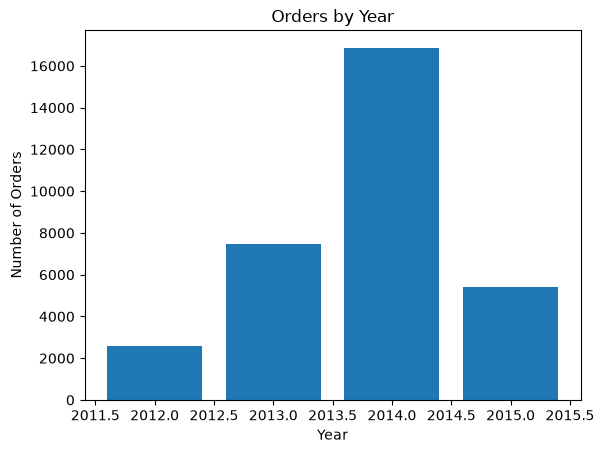

In [146]:
plt.bar(orders_by_year.index, orders_by_year.values)
plt.title('Orders by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.show ()



In [147]:
revenue_by_year = orders.groupby(orders['created_at'].dt.year)['price_usd'].sum()

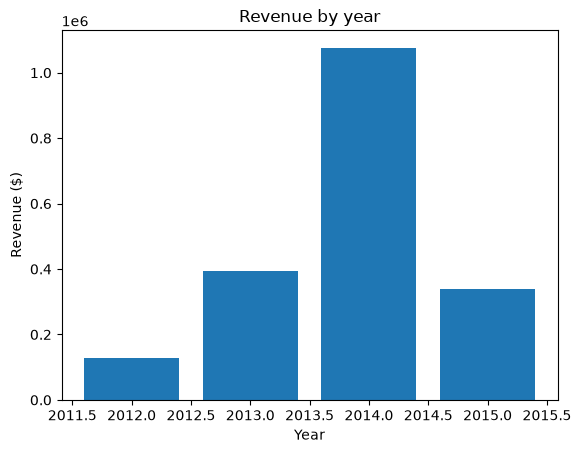

In [148]:
plt.bar(revenue_by_year.index, revenue_by_year.values)
plt.title('Revenue by year')
plt.xlabel('Year')
plt.ylabel('Revenue ($)')
plt.show()